# Stryker Crop — edytor kadrowania okiem osi (Opcja B)

## Idea

Dla zdjecia przeszukujemy przestrzen kadrow (sliding window, kilka skal i proporcji), kazdy kadr -> CLIP -> rzut na `v_clean3` (po neutralizacji), wybieramy kadr **maksymalizujacy os**. System przycina do ludzkiej historii — robi to, co redaktor olowkiem na stykowce.

## Uczciwosc i pulapki (wbudowane zabezpieczenia)

- **Crop nie tworzy tresci**: dziala tam, gdzie ludzie SA, ale zle skadrowani (para z grobli), nie na pustych pejzazach. Test to uwzglednia.
- **Pulapka zoomu**: os nagradza ludzi blisko -> naiwny optymalizator maksymalnie przybliza na glowe. Zapobiegamy: dolny limit rozmiaru kadru + kara za skrajne proporcje.
- **Baseline**: rzut losowych kadrow + pelnego obrazu. Najlepszy kadr musi bic losowy — inaczej os nie niesie sygnalu kadrowania.

## Wejscie
Zdjecia w `/content/crop_input/`. Osie z Drive.


## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch 2>/dev/null


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import torch, open_clip
np.set_printoptions(precision=4, suppress=True)

DRIVE = Path('/content/drive/MyDrive/fsa_data')
INPUT = Path('/content/crop_input'); INPUT.mkdir(exist_ok=True)

with np.load(DRIVE/'akt1_axes.npz') as d:
    v_hole, v_sharp = d['v_hole'], d['v_sharp']
with np.load(DRIVE/'akt2b_axes.npz') as d:
    v_clean3 = d['v_clean3']; v_bright = d['v_bright']; v_contrast = d['v_contrast']
Q, _ = np.linalg.qr(np.stack([v_hole, v_sharp, v_bright, v_contrast], axis=1))
def neutralize(e):
    e = np.atleast_2d(e)
    return e - (e @ Q) @ Q.T

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model = model.to(device).eval()
print(f'OK: os + neutralizator; CLIP na {device}')
print(f'Wgraj zdjecia do: {INPUT}')


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

OK: os + neutralizator; CLIP na cuda
Wgraj zdjecia do: /content/crop_input


## 1. Scoring kadru + generator kandydatow

In [ ]:
@torch.no_grad()
def score_crops_batch(pil_full, boxes, batch=64):
    scores = np.zeros(len(boxes))
    for i in range(0, len(boxes), batch):
        chunk = boxes[i:i+batch]
        tens = torch.stack([preprocess(pil_full.crop(b)) for b in chunk]).to(device)
        e = model.encode_image(tens)
        e = (e / e.norm(dim=-1, keepdim=True)).float().cpu().numpy().astype(np.float64)
        scores[i:i+len(chunk)] = neutralize(e) @ v_clean3
    return scores

def generate_crops(W, H, scales=(0.9,0.75,0.6,0.45), ars=(1.5,1.0,0.667), stride_frac=0.12):
    # Zabezpieczenia przeciw pulapce zoomu: min skala 0.45, ar 0.667-1.5 (bez paskow)
    boxes = []
    for s in scales:
        for ar in ars:
            ch = int(min(H*s, W*s/ar)); cw = int(ch*ar)
            if cw > W or ch > H or cw < 80 or ch < 80: continue
            sx, sy = max(1,int(cw*stride_frac)), max(1,int(ch*stride_frac))
            for top in range(0, H-ch+1, sy):
                for left in range(0, W-cw+1, sx):
                    boxes.append((left, top, left+cw, top+ch))
    return boxes

print('Funkcje gotowe (min skala 0.45, ar 0.67-1.5)')


Funkcje gotowe (min skala 0.45, ar 0.67-1.5)


## 2. Najlepszy kadr + baseline

In [ ]:
@torch.no_grad()
def full_score(pil):
    t = preprocess(pil).unsqueeze(0).to(device)
    e = model.encode_image(t); e = (e/e.norm(dim=-1,keepdim=True)).float().cpu().numpy().astype(np.float64)
    return float(neutralize(e) @ v_clean3)

def stryker_crop(path, topk=1):
    pil = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    W, H = pil.size
    boxes = generate_crops(W, H)
    if len(boxes) < 5: return None
    scores = score_crops_batch(pil, boxes)
    s_full = full_score(pil)
    order = np.argsort(scores)[::-1]
    best_idx = order[:topk]
    return dict(pil=pil, boxes=[boxes[i] for i in best_idx],
                best_score=float(scores[order[0]]), full_score=s_full,
                median_crop=float(np.median(scores)), max_crop=float(scores.max()),
                n_crops=len(boxes),
                improve_vs_full=float(scores[order[0]] - s_full),
                improve_vs_median=float(scores[order[0]] - np.median(scores)))

print('stryker_crop() gotowa')


stryker_crop() gotowa


## 3. Uruchom + wizualizacja

Zdjec: 12


/tmp/ipykernel_3440/2324972478.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(neutralize(e) @ v_clean3)


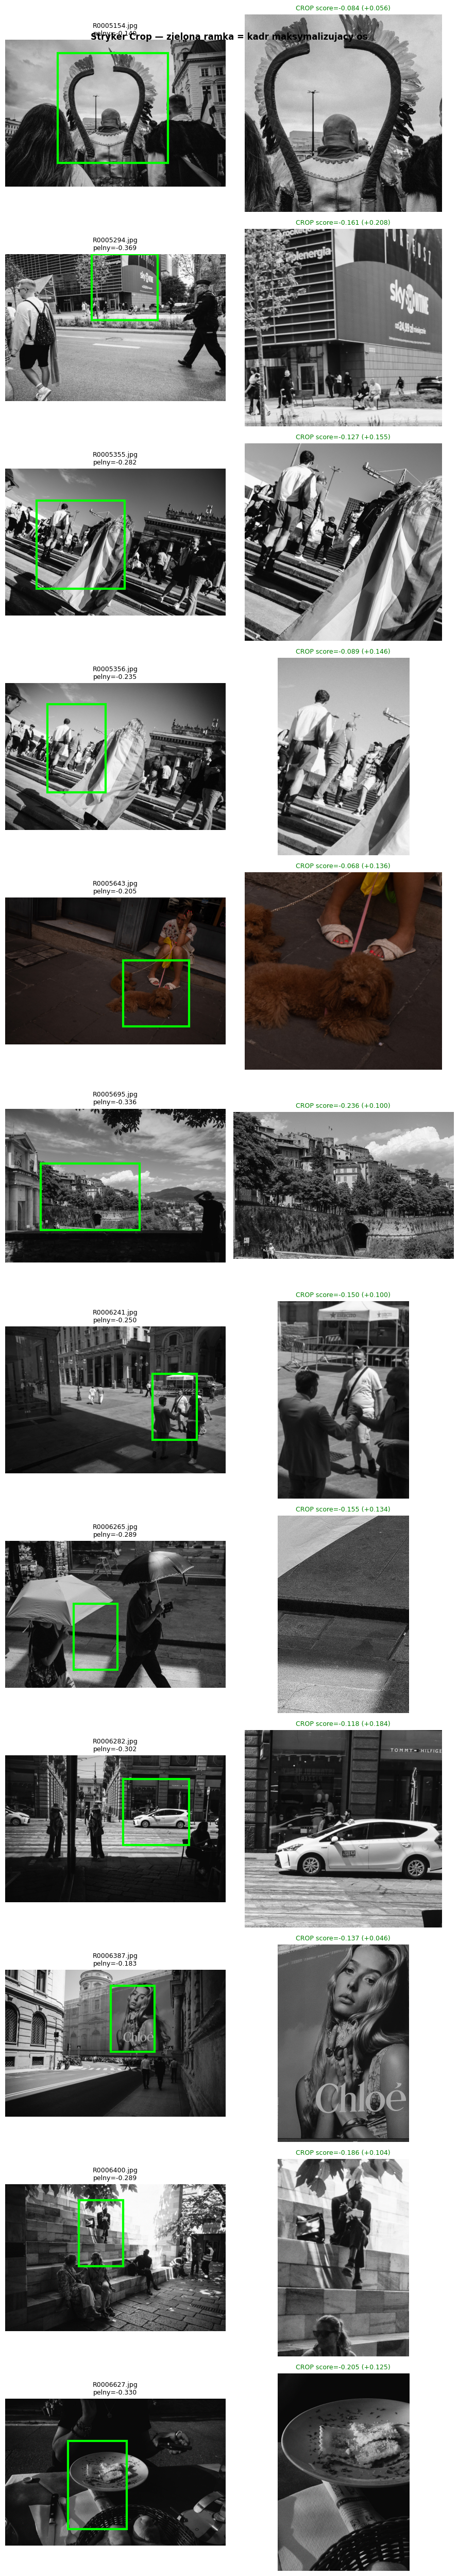

In [ ]:
EXTS=('.jpg','.jpeg','.png','.webp')
files = sorted([f for f in INPUT.iterdir() if f.suffix.lower() in EXTS])
print(f'Zdjec: {len(files)}')

results = []
for f in files:
    r = stryker_crop(f)
    if r: r['name'] = f.name; results.append(r)

from matplotlib.patches import Rectangle
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(9, 4.2*n))
if n == 1: axes = axes.reshape(1,2)
for i, r in enumerate(results):
    pil = r['pil']; box = r['boxes'][0]
    axes[i,0].imshow(pil); axes[i,0].axis('off')
    l,t,rr,b = box
    axes[i,0].add_patch(Rectangle((l,t), rr-l, b-t, fill=False, edgecolor='lime', lw=3))
    axes[i,0].set_title(f"{r['name']}\npelny={r['full_score']:+.3f}", fontsize=9)
    axes[i,1].imshow(pil.crop(box)); axes[i,1].axis('off')
    axes[i,1].set_title(f"CROP score={r['best_score']:+.3f} (+{r['improve_vs_full']:.3f})", fontsize=9, color='green')
plt.suptitle('Stryker Crop — zielona ramka = kadr maksymalizujacy os', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(DRIVE/'stryker_crop_results.png', dpi=90, bbox_inches='tight'); plt.show()


## 4. Kontrola — czy crop bije baseline

In [ ]:
print('Czy najlepszy kadr bije pelny obraz i mediane kadrow?\n')
print(f'{"zdjecie":30} {"pelny":>8} {"best":>8} {"d_full":>8} {"d_med":>8}  werdykt')
n_improve = 0
for r in results:
    improved = r['improve_vs_full'] > 0.02
    n_improve += improved
    flag = 'crop pomaga' if improved else 'pelny OK / brak tresci'
    print(f"{r['name'][:30]:30} {r['full_score']:+8.3f} {r['best_score']:+8.3f} "
          f"{r['improve_vs_full']:+8.3f} {r['improve_vs_median']:+8.3f}  {flag}")
print(f'\nCrop poprawil os w {n_improve}/{len(results)} zdjeciach (prog +0.02)')
print('Brak poprawy na zdjeciu BEZ ludzi jest POPRAWNY — crop nie tworzy tresci.')


Czy najlepszy kadr bije pelny obraz i mediane kadrow?

zdjecie                           pelny     best   d_full    d_med  werdykt
R0005154.jpg                     -0.140   -0.084   +0.056   +0.181  crop pomaga
R0005294.jpg                     -0.369   -0.161   +0.208   +0.161  crop pomaga
R0005355.jpg                     -0.282   -0.127   +0.155   +0.174  crop pomaga
R0005356.jpg                     -0.235   -0.089   +0.146   +0.213  crop pomaga
R0005643.jpg                     -0.205   -0.068   +0.136   +0.207  crop pomaga
R0005695.jpg                     -0.336   -0.236   +0.100   +0.104  crop pomaga
R0006241.jpg                     -0.250   -0.150   +0.100   +0.158  crop pomaga
R0006265.jpg                     -0.289   -0.155   +0.134   +0.151  crop pomaga
R0006282.jpg                     -0.302   -0.118   +0.184   +0.191  crop pomaga
R0006387.jpg                     -0.183   -0.137   +0.046   +0.129  crop pomaga
R0006400.jpg                     -0.289   -0.186   +0.104   +0.125  c

## 5. Mapa cieplna osi — gdzie jest ludzka historia

Mapa cieplna dla: R0005154.jpg


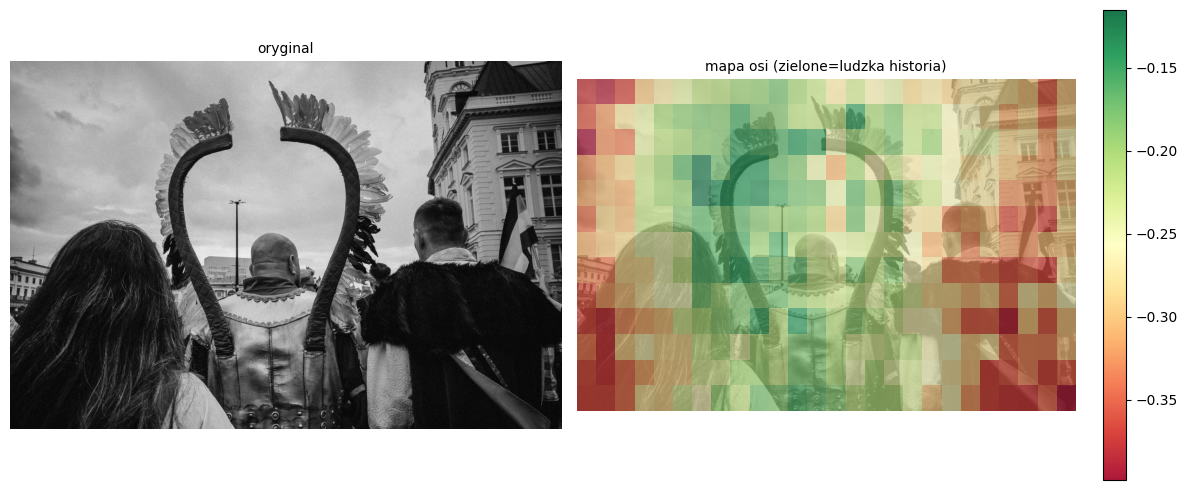

In [ ]:
def axis_heatmap(path, win_frac=0.5, stride_frac=0.08):
    pil = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    W,H = pil.size
    cw = ch = int(min(W,H)*win_frac)
    sx = sy = max(1,int(cw*stride_frac))
    xs = list(range(0, W-cw+1, sx)); ys = list(range(0, H-ch+1, sy))
    boxes = [(x,y,x+cw,y+ch) for y in ys for x in xs]
    sc = score_crops_batch(pil, boxes).reshape(len(ys), len(xs))
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].imshow(pil); ax[0].axis('off'); ax[0].set_title('oryginal', fontsize=10)
    im = ax[1].imshow(sc, cmap='RdYlGn', extent=[0,W,H,0], alpha=0.9)
    ax[1].imshow(pil, alpha=0.35, extent=[0,W,H,0])
    ax[1].axis('off'); ax[1].set_title('mapa osi (zielone=ludzka historia)', fontsize=10)
    plt.colorbar(im, ax=ax[1], fraction=0.046)
    plt.tight_layout(); plt.show()

if results:
    print(f"Mapa cieplna dla: {results[6]['name']}")
    axis_heatmap(INPUT/results[6]['name'])
print(results)
i = 0
for _ in results:
  print(f"Mapa cieplna dla: {results[i]['name']}")
  axis_heatmap(INPUT/results[i]['name'])
  i = i + 1

## 6. Interpretacja

Na co patrzec:
- **Crop na zdjeciach z ludzmi zle skadrowanymi** (jak grobla FSA): czy zielona ramka wycina grupe ludzi?
- **Pulapka zoomu**: czy najlepsze kadry to sensowne kompozycje, czy zblizenia na jedna glowe?
- **Zdjecia bez ludzi**: brak poprawy jest OK — crop nie fabrykuje tresci.
- **Mapa cieplna**: czy zielone rejony pokrywaja sie z ludzmi?

### Nastepny krok
Jesli crop dziala na zdjeciach z ludzmi — mamy dzialajacy edytor (Opcja B) i dowod, ze os niesie informacje kompozycyjna (wsparcie dla T2). Potem: Opcja A (krytyk LoRA z higiena dziurek).
